# 1.8. Решение задач изгиба балок с использованием сингулярных функций

> Источник: [`docs.sympy.org/latest/modules/physics/continuum_mechanics/beam_problems.html`](https://docs.sympy.org/latest/modules/physics/continuum_mechanics/beam_problems.html)

Чтобы сделать этот документ более удобным для чтения, включите улучшенный (типографский) вывод:

In [ ]:
from sympy import init_printing, symbols
x, y, z = symbols('x y z')
init_printing(use_unicode=True)

Плоская балка — это конструктивный элемент, который воспринимает нагрузки за счёт сопротивления внутренним поперечным силам и изгибающим моментам. Свойства балки определяются её длиной, условиями закрепления, моментом инерции поперечного сечения и модулем упругости. В SymPy двумерная балка создаётся путём указания следующих параметров:

- Длина (Length)
- Модуль упругости (Elastic Modulus)
- Момент инерции площади (Second Moment of Area)
- Переменная (Variable): Символ, обозначающий координату вдоль длины балки. По умолчанию используется `Symbol(x)`.
- Граничные условия (Boundary Conditions)
	- bc_slope : Граничные условия для угла наклона.
	- bc_deflection : Граничные условия для прогиба.
- Распределение нагрузки (Load Distribution)

После того как перечисленные выше параметры заданы, для вычисления полезной информации о нагруженной балке используются следующие методы:

- `solve_for_reaction_loads()`
- `shear_force()`
- `bending_moment()`
- `slope()`

Ниже приведены примеры различных двумерных задач изгиба балок.

## Пример 1

Консольная балка длиной 9 метров с постоянной распределённой нагрузкой 8 кН/м, приложенной на участке от 0 до 5 метров от заделки. На расстоянии 5 метров от заделки приложен против часовой стрелки момент 50 кН·м. На свободном конце балки приложена сосредоточенная нагрузка 12 кН вниз.

```  y
    ^
    |
\\|    8 кН/м
\\|_________________
\\|| | | | | | | | |             12 кН
\\|V V V V V V V V V               |
\\|________________|_______________V
\\|                |               |
\\o - - - - - - - -⭯ 50 кН·м - - - | - - -> x
\\|________________|_______________|
\\|                                :
\\|----------------|---------------|
        5.0 м            4.0 м
```

**Примечание:**

Пользователь может выбирать собственное правило знаков. В данном случае положительными считаются силы, направленные вниз, и момент, направленный против часовой стрелки.

Балка должна быть инициализирована длиной, модулем упругости и моментом инерции площади. Эти величины могут быть как символами, так и числами.

In [2]:
from sympy.physics.continuum_mechanics.beam import Beam
E, I = symbols('E, I')
b = Beam(9, E, I)


Три нагрузки прикладываются к балке с помощью метода `apply_load()`. Этот метод поддерживает сосредоточенные силы, сосредоточенные моменты и полиномиально распределенные нагрузки любого порядка, т.е. :math:`c, cx, cx^2, cx^3, ldots`.

Сосредоточенная сила 12 кН направлена в отрицательном направлении, приложена в точке 9 метров, а полиномиальный порядок указан как -1:

In [3]:
b.apply_load(12, 9, -1)

Затем для доступа к функции нагрузки в форме сингулярных функций можно использовать атрибут `load`:

In [4]:
b.load

Аналогично, положительный момент может быть приложен с полиномиальным порядком -2:

In [5]:
b.apply_load(50, 5, -2)

Распределенная нагрузка имеет порядок 0 и действует от x=0 до x=5:

In [6]:
b.apply_load(8, 0, 0, end=5)

Защемленный конец накладывает два граничных условия: 1) отсутствие вертикального прогиба и 2) отсутствие угла поворота. Они задаются путём добавления кортежей из значений x и соответствующих значений прогиба или угла наклона:

In [7]:
b.bc_deflection.append((0, 0))
b.bc_slope.append((0, 0))

Эти граничные условия приводят к появлению неизвестных реактивных силы и момента, которые необходимо приложить к балке для поддержания статического равновесия:

In [8]:
R, M = symbols('R, M')
b.apply_load(R, 0, -1)
b.apply_load(M, 0, -2)
b.load

Эти две переменные можно выразить через приложенные нагрузки, после чего можно отобразить итоговую нагрузку:

In [9]:
b.solve_for_reaction_loads(R, M)
b.reaction_loads
b.load

На этом этапе балка полностью определена, и вычисляются внутренние поперечные силы и изгибающие моменты:

In [10]:
b.shear_force()

In [11]:
b.bending_moment()

Их можно визуализировать, вызвав соответствующие методы построения графиков:

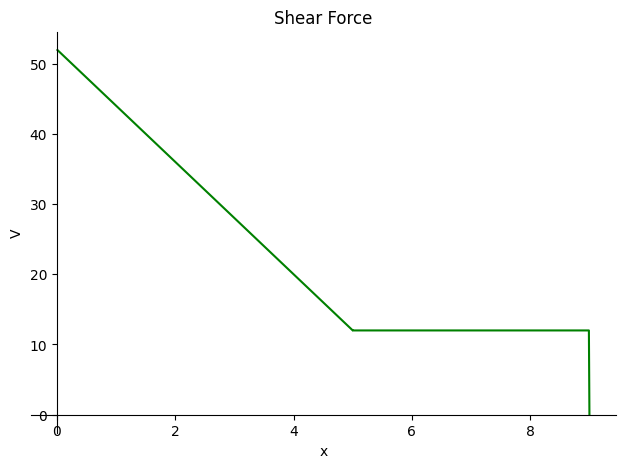

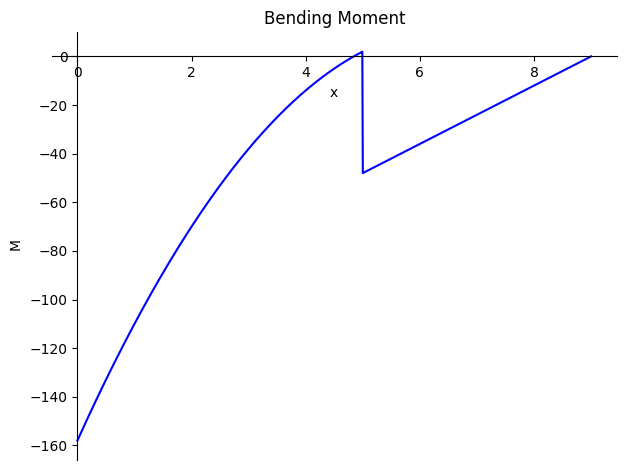

In [18]:
b.plot_shear_force();
b.plot_bending_moment();

Под нагрузкой балка будет деформироваться, а угол наклона и прогиб можно определить с помощью:

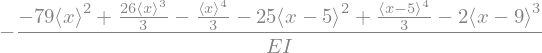

In [13]:
b.slope()
b.deflection()

Углы наклона и прогибы балки можно построить на графике при условии, что для модуля упругости и момента инерции заданы числовые значения:

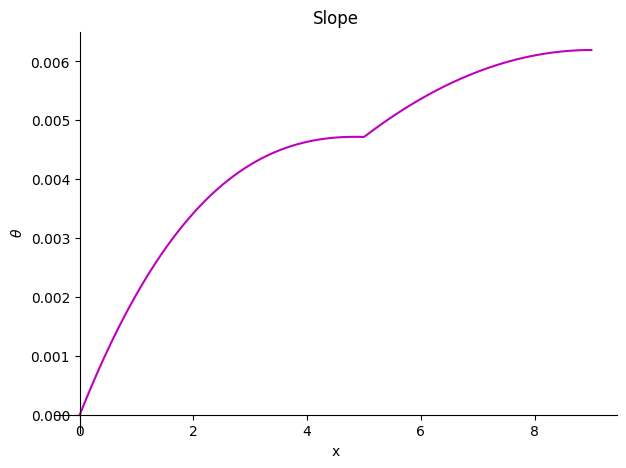

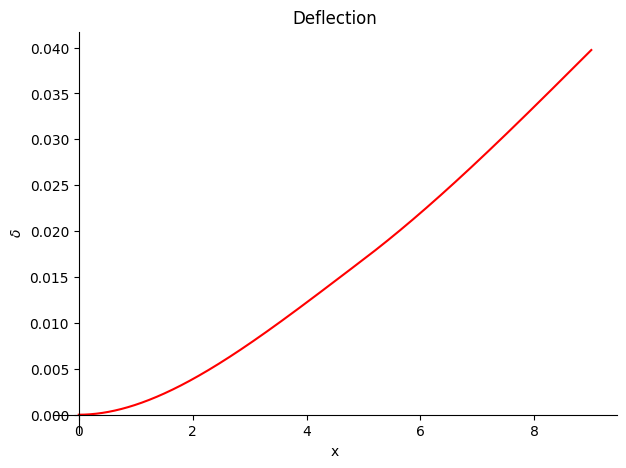

In [16]:
b.plot_slope(subs={E: 20E9, I: 3.25E-6});
b.plot_deflection(subs={E: 20E9, I: 3.25E-6});

Все графики можно отобразить на одном рисунке с помощью:

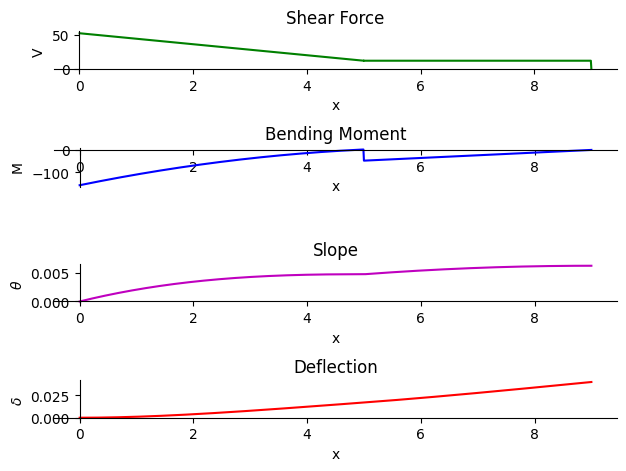

In [17]:
b.plot_loading_results(subs={E: 20E9, I: 3.25E-6});

## Пример 2

Имеется балка длиной 30 метров. На конце балки приложен момент величиной 120 Н·м в направлении против часовой стрелки. Сосредоточенная сила величиной 8 Н приложена к балке сверху в начальной точке. Под балкой расположены две шарнирно-неподвижные опоры. Одна на конце, а другая на расстоянии 10 метров от начала. Прогиб ограничен на обеих опорах.

```
|| 8 N                                       ↺ 120 Nm
\/______________________________________________|
|_______________________________________________|
            /\                                 /\
|------------|---------------------------------|
    10 m                  20 m
```


> [!note]
> Используется правило знаков, при котором положительными считаются силы, направленные вниз, и момент, направленный против часовой стрелки.

In [8]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b = Beam(30, E, I)
b.apply_load(8, 0, -1)
b.apply_load(R1, 10, -1)
b.apply_load(R2, 30, -1)
b.apply_load(120, 30, -2)
b.bc_deflection.append((10, 0))
b.bc_deflection.append((30, 0))
b.solve_for_reaction_loads(R1, R2)

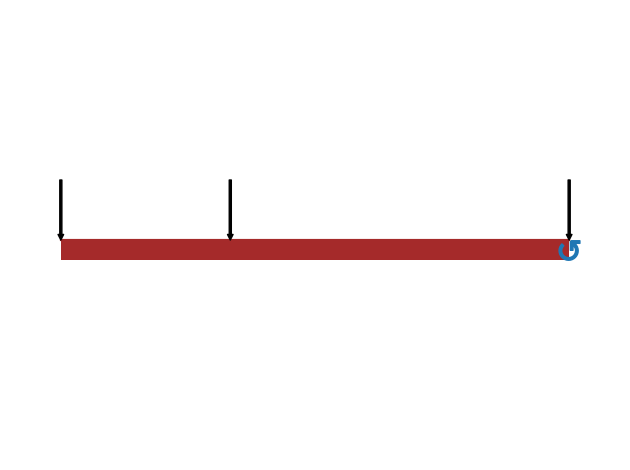

In [9]:
b.draw().show();

In [4]:
b.reaction_loads

{R1: -18, R2: 10}

In [5]:
b.load

8*SingularityFunction(x, 0, -1) - 18*SingularityFunction(x, 10, -1) + 120*SingularityFunction(x, 30, -2) + 10*SingularityFunction(x, 30, -1)

In [13]:
b.shear_force()

-8*SingularityFunction(x, 0, 0) + 18*SingularityFunction(x, 10, 0) - 120*SingularityFunction(x, 30, -1) - 10*SingularityFunction(x, 30, 0)

In [14]:
b.bending_moment()

-8*SingularityFunction(x, 0, 1) + 18*SingularityFunction(x, 10, 1) - 120*SingularityFunction(x, 30, 0) - 10*SingularityFunction(x, 30, 1)

In [15]:
b.slope()

(4*SingularityFunction(x, 0, 2) - 9*SingularityFunction(x, 10, 2) + 120*SingularityFunction(x, 30, 1) + 5*SingularityFunction(x, 30, 2) - 1600/3)/(E*I)

In [16]:
b.deflection()

(-1600*x/3 + 4*SingularityFunction(x, 0, 3)/3 - 3*SingularityFunction(x, 10, 3) + 60*SingularityFunction(x, 30, 2) + 5*SingularityFunction(x, 30, 3)/3 + 4000)/(E*I)

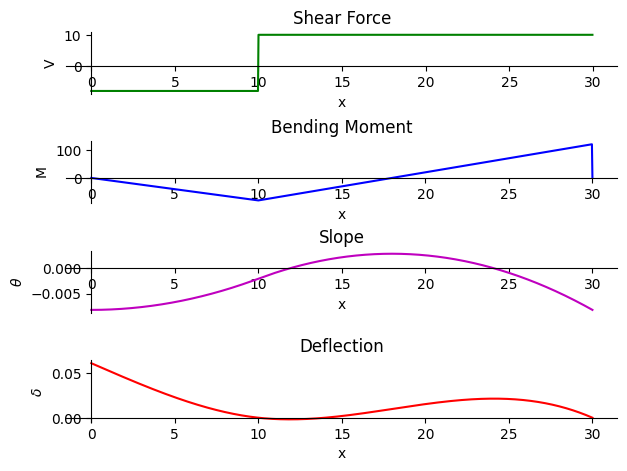

In [12]:
b.plot_loading_results(subs={E: 20E9, I: 3.25E-6});

Пример 3
---------

Балка длиной 6 метров имеет шарнирно-подвижную опору в начале и шарнирно-неподвижную опору в конце. Посередине балки приложен момент 1.5 кН·м против часовой стрелки. Равномерно распределенная нагрузка 3 кН/м и линейно возрастающая нагрузка с интенсивностью 1 кН/м/м приложены от середины до конца балки.

```
                            ramp load = 1 KN/m/m
                          constant load = 3 KN/m
                       |------------------------|
                     ↺ 1.5 KN-m
 ______________________|________________________
|_______________________________________________|
o                      |                       /\
|----------------------|-----------------------|
        3.0 m                     3.0 m
```

> [!note]
> Используется правило знаков, при котором положительными считаются силы, направленные вниз, и момент, направленный против часовой стрелки.

In [18]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols, plot, S
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b = Beam(6, E, I)
b.apply_load(R1, 0, -1)
b.apply_load(-S(3)/2, 3, -2)
b.apply_load(3, 3, 0)
b.apply_load(1, 3, 1)
b.apply_load(R2, 6, -1)
b.bc_deflection.append((0, 0))
b.bc_deflection.append((6, 0))
b.solve_for_reaction_loads(R1, R2)

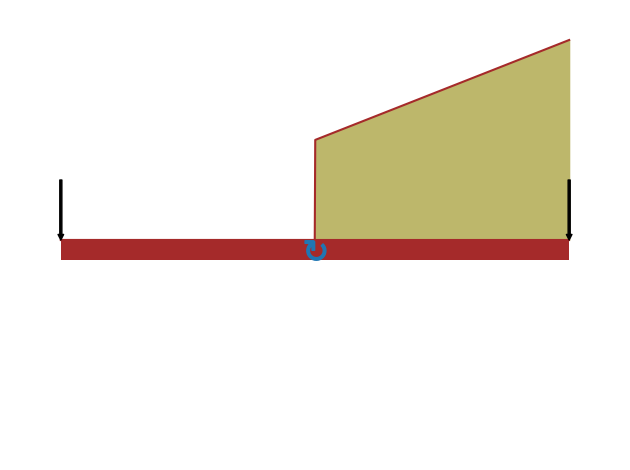

{R1: -11/4, R2: -43/4}

In [19]:
b.draw().show()
b.reaction_loads

In [20]:
b.load

-11*SingularityFunction(x, 0, -1)/4 - 3*SingularityFunction(x, 3, -2)/2 + 3*SingularityFunction(x, 3, 0) + SingularityFunction(x, 3, 1) - 43*SingularityFunction(x, 6, -1)/4

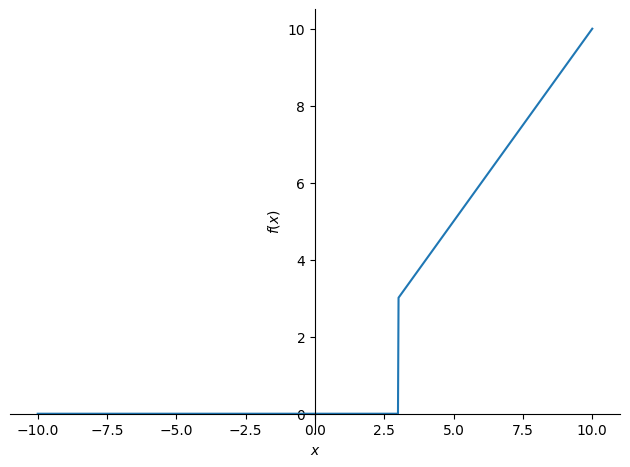

In [22]:
plot(b.load);

In [23]:
b.shear_force()

11*SingularityFunction(x, 0, 0)/4 + 3*SingularityFunction(x, 3, -1)/2 - 3*SingularityFunction(x, 3, 1) - SingularityFunction(x, 3, 2)/2 + 43*SingularityFunction(x, 6, 0)/4

In [24]:
b.bending_moment()

11*SingularityFunction(x, 0, 1)/4 + 3*SingularityFunction(x, 3, 0)/2 - 3*SingularityFunction(x, 3, 2)/2 - SingularityFunction(x, 3, 3)/6 + 43*SingularityFunction(x, 6, 1)/4

In [25]:
b.slope()

(-11*SingularityFunction(x, 0, 2)/8 - 3*SingularityFunction(x, 3, 1)/2 + SingularityFunction(x, 3, 3)/2 + SingularityFunction(x, 3, 4)/24 - 43*SingularityFunction(x, 6, 2)/8 + 78/5)/(E*I)

In [26]:
b.deflection()

(78*x/5 - 11*SingularityFunction(x, 0, 3)/24 - 3*SingularityFunction(x, 3, 2)/4 + SingularityFunction(x, 3, 4)/8 + SingularityFunction(x, 3, 5)/120 - 43*SingularityFunction(x, 6, 3)/24)/(E*I)

Пример 4
---------

Консольная балка с вылетом длиной 8 метров имеет шарнирно-неподвижную опору на расстоянии 1 метр от начала и опирается на шарнирно-подвижную опору за 1 метр до другого конца. Она подвергается действию равномерно распределенной нагрузки 10 КН/м от начальной точки до точки, находящейся на расстоянии 2 метров от нее. Две сосредоточенные силы 20 КН и 8 КН приложены на расстоянии 5 метров и 7.5 метров от начальной точки соответственно.

```
                                      ---> x
                                      |
                                      v y
  10 KN/m
_____________                 20 KN         8 KN
| | | | | | |                  |             |
V V V V V V V                  V             V
 _______________________________________________
|_______________________________________________|
      /\                                  O
|-----|------|-----------------|----------|--|--|
   1m    1m          3m              2m   .5m .5m
```

In [27]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E,I,M,V = symbols('E I M V')
b = Beam(8, E, I)
E,I,R1,R2 = symbols('E I R1 R2')
b.apply_load(R1, 1, -1)
b.apply_load(R2, 7, -1)
b.apply_load(10, 0, 0, end=2)
b.apply_load(20, 5, -1)
b.apply_load(8, 7.5, -1)
b.solve_for_reaction_loads(R1, R2)
b.reaction_loads

{R1: -26, R2: -22}

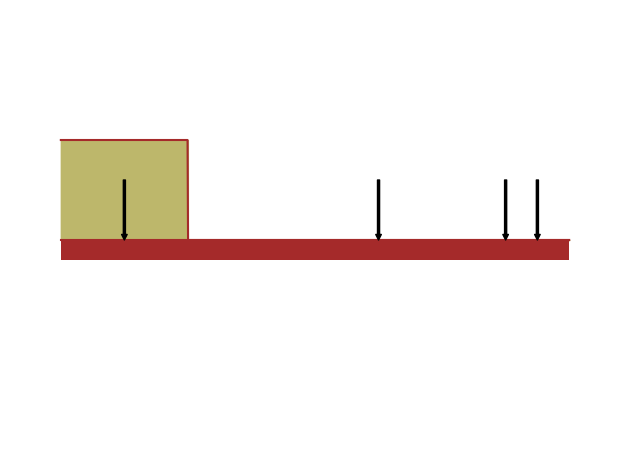

In [35]:
b.draw().show()

In [29]:
b.load

10*SingularityFunction(x, 0, 0) - 26*SingularityFunction(x, 1, -1) - 10*SingularityFunction(x, 2, 0) + 20*SingularityFunction(x, 5, -1) - 22*SingularityFunction(x, 7, -1) + 8*SingularityFunction(x, 7.5, -1)

In [30]:
b.shear_force()

-10*SingularityFunction(x, 0, 1) + 26*SingularityFunction(x, 1, 0) + 10*SingularityFunction(x, 2, 1) - 20*SingularityFunction(x, 5, 0) + 22*SingularityFunction(x, 7, 0) - 8*SingularityFunction(x, 7.5, 0)

In [31]:
b.bending_moment()

-5*SingularityFunction(x, 0, 2) + 26*SingularityFunction(x, 1, 1) + 5*SingularityFunction(x, 2, 2) - 20*SingularityFunction(x, 5, 1) + 22*SingularityFunction(x, 7, 1) - 8*SingularityFunction(x, 7.5, 1)

In [32]:
b.bc_deflection = [(1, 0), (7, 0)]

In [33]:
b.slope()

(5*SingularityFunction(x, 0, 3)/3 - 13*SingularityFunction(x, 1, 2) - 5*SingularityFunction(x, 2, 3)/3 + 10*SingularityFunction(x, 5, 2) - 11*SingularityFunction(x, 7, 2) + 4*SingularityFunction(x, 7.5, 2) + 679/24)/(E*I)

In [34]:
b.deflection()

(679*x/24 + 5*SingularityFunction(x, 0, 4)/12 - 13*SingularityFunction(x, 1, 3)/3 - 5*SingularityFunction(x, 2, 4)/12 + 10*SingularityFunction(x, 5, 3)/3 - 11*SingularityFunction(x, 7, 3)/3 + 4*SingularityFunction(x, 7.5, 3)/3 - 689/24)/(E*I)

Пример 5
---------

Консольная балка длиной 6 метров находится под действием направленной вниз равномерно распределенной нагрузки интенсивностью 4,0 кН/м, приложенной от начальной точки на участке длиной 2 метра. От середины и до конца балки приложена линейно возрастающая нагрузка с интенсивностью 1 кН/м/м. Сосредоточенная сила 12 кН приложена в том же направлении на расстоянии 4 метров от начала.

```
  ---> x                             .
  |                                . |
  v y                    12 KN   . | |
                           |   . | | |
                           V . | | | |
\\\\|   4 KN/m             . | | | | |
\\\\|___________         . 1 KN/m/m| |
\\\\|| | | | | |       . V V V V V V V
\\\\|V V V V V V     |---------------|
\\\\|________________________________
\\\\|________________________________|
\\\\|          :          :          :
\\\\|----------|-----|----|----------|
        2.0 m     1m   1m      2.0 m
```

In [36]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E,I,M,V = symbols('E I M V')
b = Beam(6, E, I)
b.apply_load(V, 0, -1)
b.apply_load(M, 0, -2)
b.apply_load(4, 0, 0, end=2)
b.apply_load(12, 4, -1)
b.apply_load(1, 3, 1, end=6)
b.solve_for_reaction_loads(V, M)
b.reaction_loads

{V: -49/2, M: 157/2}

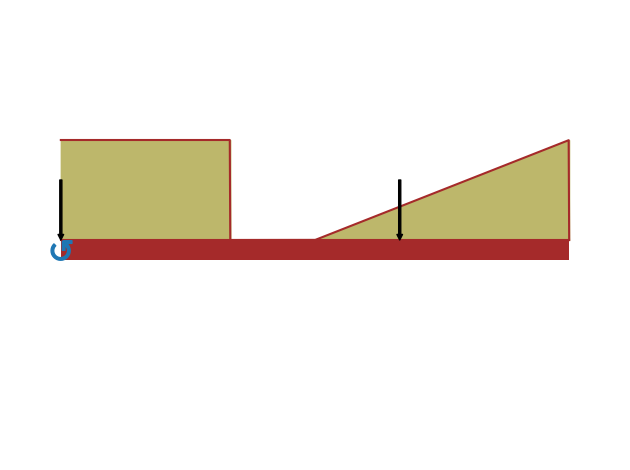

In [38]:
b.draw().show()

In [39]:
b.load

157*SingularityFunction(x, 0, -2)/2 - 49*SingularityFunction(x, 0, -1)/2 + 4*SingularityFunction(x, 0, 0) - 4*SingularityFunction(x, 2, 0) + SingularityFunction(x, 3, 1) + 12*SingularityFunction(x, 4, -1) - 3*SingularityFunction(x, 6, 0) - SingularityFunction(x, 6, 1)

In [40]:
b.shear_force()

-157*SingularityFunction(x, 0, -1)/2 + 49*SingularityFunction(x, 0, 0)/2 - 4*SingularityFunction(x, 0, 1) + 4*SingularityFunction(x, 2, 1) - SingularityFunction(x, 3, 2)/2 - 12*SingularityFunction(x, 4, 0) + 3*SingularityFunction(x, 6, 1) + SingularityFunction(x, 6, 2)/2

In [41]:
b.bending_moment()

-157*SingularityFunction(x, 0, 0)/2 + 49*SingularityFunction(x, 0, 1)/2 - 2*SingularityFunction(x, 0, 2) + 2*SingularityFunction(x, 2, 2) - SingularityFunction(x, 3, 3)/6 - 12*SingularityFunction(x, 4, 1) + 3*SingularityFunction(x, 6, 2)/2 + SingularityFunction(x, 6, 3)/6

In [42]:
b.bc_deflection = [(0, 0)]
b.bc_slope = [(0, 0)]
b.slope()

-(-157*SingularityFunction(x, 0, 1)/2 + 49*SingularityFunction(x, 0, 2)/4 - 2*SingularityFunction(x, 0, 3)/3 + 2*SingularityFunction(x, 2, 3)/3 - SingularityFunction(x, 3, 4)/24 - 6*SingularityFunction(x, 4, 2) + SingularityFunction(x, 6, 3)/2 + SingularityFunction(x, 6, 4)/24)/(E*I)

In [43]:
b.deflection()

-(-157*SingularityFunction(x, 0, 2)/4 + 49*SingularityFunction(x, 0, 3)/12 - SingularityFunction(x, 0, 4)/6 + SingularityFunction(x, 2, 4)/6 - SingularityFunction(x, 3, 5)/120 - 2*SingularityFunction(x, 4, 3) + SingularityFunction(x, 6, 4)/8 + SingularityFunction(x, 6, 5)/120)/(E*I)



Пример 6
---------

Балка с консольным свесом длиной 11 метров нагружена равномерно распределенной нагрузкой 2 кН/м на участке от 2 до 6 метров от начальной точки. Она имеет шарнирное закрепление в начальной точке и опирается на катковую опору на расстоянии 8 метров от этого конца. Также на консольном конце приложен момент 5 кН·м, направленный против часовой стрелки.

```
               2 KN/m                         ---> x
           _________________                  |
           | | | | | | | | |                  v y
           V V V V V V V V V                        ↺ 5 KN-m
  ____________________________________________________|
 O____________________________________________________|
/ \                                   /\
 |--------|----------------|----------|---------------|
     2m           4m            2m            3m
```

In [44]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
R1, R2 = symbols('R1, R2')
E, I = symbols('E, I')
b = Beam(11, E, I)
b.apply_load(R1, 0, -1)
b.apply_load(2, 2, 0, end=6)
b.apply_load(R2, 8, -1)
b.apply_load(5, 11, -2)
b.solve_for_reaction_loads(R1, R2)
b.reaction_loads

{R1: -37/8, R2: -27/8}

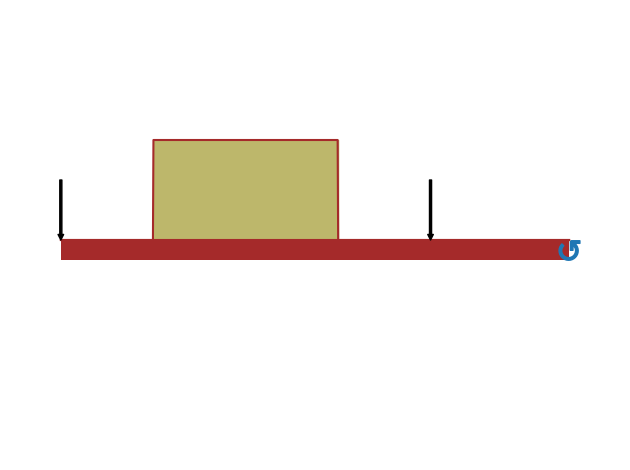

In [51]:
b.draw().show()

In [46]:
b.load

-37*SingularityFunction(x, 0, -1)/8 + 2*SingularityFunction(x, 2, 0) - 2*SingularityFunction(x, 6, 0) - 27*SingularityFunction(x, 8, -1)/8 + 5*SingularityFunction(x, 11, -2)

In [47]:
b.shear_force()

37*SingularityFunction(x, 0, 0)/8 - 2*SingularityFunction(x, 2, 1) + 2*SingularityFunction(x, 6, 1) + 27*SingularityFunction(x, 8, 0)/8 - 5*SingularityFunction(x, 11, -1)

In [48]:
b.bending_moment()

37*SingularityFunction(x, 0, 1)/8 - SingularityFunction(x, 2, 2) + SingularityFunction(x, 6, 2) + 27*SingularityFunction(x, 8, 1)/8 - 5*SingularityFunction(x, 11, 0)

In [49]:
b.bc_deflection = [(0, 0), (8, 0)]
b.slope()

(-37*SingularityFunction(x, 0, 2)/16 + SingularityFunction(x, 2, 3)/3 - SingularityFunction(x, 6, 3)/3 - 27*SingularityFunction(x, 8, 2)/16 + 5*SingularityFunction(x, 11, 1) + 36)/(E*I)

In [50]:
b.deflection()

(36*x - 37*SingularityFunction(x, 0, 3)/48 + SingularityFunction(x, 2, 4)/12 - SingularityFunction(x, 6, 4)/12 - 9*SingularityFunction(x, 8, 3)/16 + 5*SingularityFunction(x, 11, 2)/2)/(E*I)

Пример 7
---------

Имеется балка длиной `l`, защемленная с обоих концов. В середине балки приложена сосредоточенная сила величиной `F`, направленная вниз.

```
                                      ^ y
                                      |
                                      ---> x
\\\\|                  F                  |\\\\
\\\\|                  |                  |\\\\
\\\\|                  V                  |\\\\
\\\\|_____________________________________|\\\\
\\\\|_____________________________________|\\\\
\\\\|                  :                  |\\\\
\\\\|                  :                  |\\\\
\\\\|------------------|------------------|\\\\
             l/2                l/2
```

In [52]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I, F = symbols('E I F')
l = symbols('l', positive=True)
b = Beam(l, E, I)
R1,R2 = symbols('R1  R2')
M1, M2 = symbols('M1, M2')
b.apply_load(R1, 0, -1)
b.apply_load(M1, 0, -2)
b.apply_load(R2, l, -1)
b.apply_load(M2, l, -2)
b.apply_load(-F, l/2, -1)
b.bc_deflection = [(0, 0),(l, 0)]
b.bc_slope = [(0, 0),(l, 0)]
b.solve_for_reaction_loads(R1, R2, M1, M2)
b.reaction_loads

{R1: F/2, R2: F/2, M1: -F*l/8, M2: F*l/8}

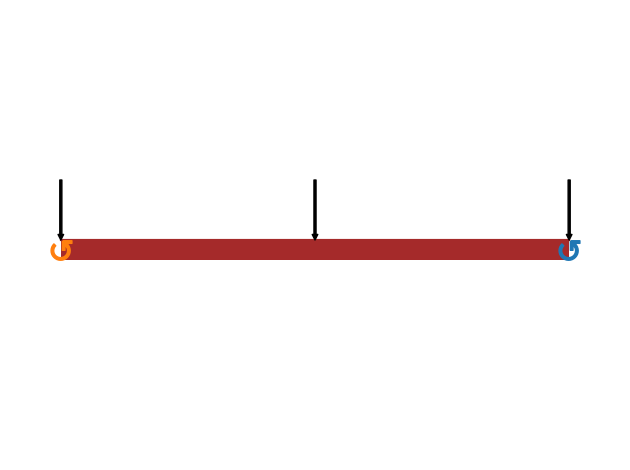

In [54]:
b.draw().show()

In [55]:
b.load

-F*l*SingularityFunction(x, 0, -2)/8 + F*l*SingularityFunction(x, l, -2)/8 + F*SingularityFunction(x, 0, -1)/2 - F*SingularityFunction(x, l/2, -1) + F*SingularityFunction(x, l, -1)/2

In [56]:
b.shear_force()

F*l*SingularityFunction(x, 0, -1)/8 - F*l*SingularityFunction(x, l, -1)/8 - F*SingularityFunction(x, 0, 0)/2 + F*SingularityFunction(x, l/2, 0) - F*SingularityFunction(x, l, 0)/2

In [57]:
b.bending_moment()

F*l*SingularityFunction(x, 0, 0)/8 - F*l*SingularityFunction(x, l, 0)/8 - F*SingularityFunction(x, 0, 1)/2 + F*SingularityFunction(x, l/2, 1) - F*SingularityFunction(x, l, 1)/2

In [58]:
b.slope()

-(F*l*SingularityFunction(x, 0, 1)/8 - F*l*SingularityFunction(x, l, 1)/8 - F*SingularityFunction(x, 0, 2)/4 + F*SingularityFunction(x, l/2, 2)/2 - F*SingularityFunction(x, l, 2)/4)/(E*I)

In [59]:
b.deflection()

-(F*l*SingularityFunction(x, 0, 2)/16 - F*l*SingularityFunction(x, l, 2)/16 - F*SingularityFunction(x, 0, 3)/12 + F*SingularityFunction(x, l/2, 3)/6 - F*SingularityFunction(x, l, 3)/12)/(E*I)

Пример 8
---------

Имеется балка длиной `4*l` с шарнирной вставкой посередине. В начале она имеет жесткую заделку, а также две катковые опоры на расстоянии `l` и `4*l` от начальной точки. Сосредоточенная сила `P` приложена на расстоянии `3*l` от начальной точки.

```
                                                   ---> x
\\\\|                                 P            |
\\\\|                                 |            v y
\\\\|                                 V
\\\\|_____________________ _______________________
\\\\|_____________________O_______________________|
\\\\|          /\                     :          /\
\\\\|         oooo                    :         oooo
\\\\|----------|-----------|----------|-----------|
         l           l          l            l
```

In [60]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E I')
l = symbols('l', positive=True)
R1, M1, R2, R3, P = symbols('R1 M1 R2 R3 P')
b1 = Beam(2*l, E, I)
b2 = Beam(2*l, E, I)
b = b1.join(b2, "hinge")
b.apply_load(M1, 0, -2)
b.apply_load(R1, 0, -1)
b.apply_load(R2, l, -1)
b.apply_load(R3, 4*l, -1)
b.apply_load(P, 3*l, -1)
b.bc_slope = [(0, 0)]
b.bc_deflection = [(0, 0), (l, 0), (4*l, 0)]
b.solve_for_reaction_loads(M1, R1, R2, R3)
b.reaction_loads

{M1: -P*l/4, R1: 3*P/4, R2: -5*P/4, R3: -P/2}

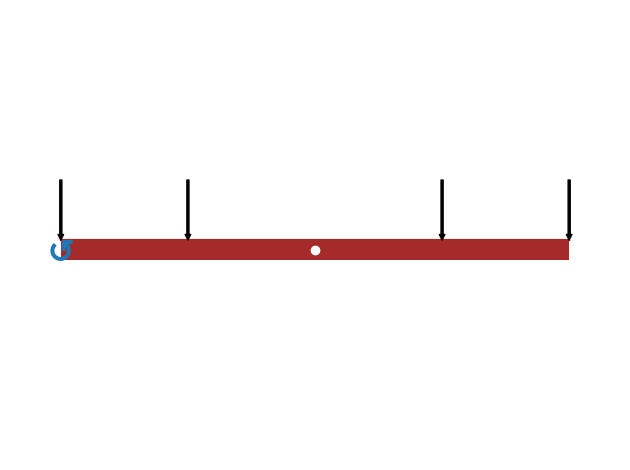

In [62]:
b.draw().show()

In [63]:
b.load

-13*P*l**2*SingularityFunction(x, 2*l, -3)/48 - P*l*SingularityFunction(x, 0, -2)/4 + 3*P*SingularityFunction(x, 0, -1)/4 - 5*P*SingularityFunction(x, l, -1)/4 + P*SingularityFunction(x, 3*l, -1) - P*SingularityFunction(x, 4*l, -1)/2

In [64]:
b.shear_force()

13*P*l**2*SingularityFunction(x, 2*l, -2)/48 + P*l*SingularityFunction(x, 0, -1)/4 - 3*P*SingularityFunction(x, 0, 0)/4 + 5*P*SingularityFunction(x, l, 0)/4 - P*SingularityFunction(x, 3*l, 0) + P*SingularityFunction(x, 4*l, 0)/2

In [65]:
b.bending_moment()

13*P*l**2*SingularityFunction(x, 2*l, -1)/48 + P*l*SingularityFunction(x, 0, 0)/4 - 3*P*SingularityFunction(x, 0, 1)/4 + 5*P*SingularityFunction(x, l, 1)/4 - P*SingularityFunction(x, 3*l, 1) + P*SingularityFunction(x, 4*l, 1)/2

In [66]:
b.slope()

-(13*P*l**2*SingularityFunction(x, 2*l, 0)/48 + P*l*SingularityFunction(x, 0, 1)/4 - 3*P*SingularityFunction(x, 0, 2)/8 + 5*P*SingularityFunction(x, l, 2)/8 - P*SingularityFunction(x, 3*l, 2)/2 + P*SingularityFunction(x, 4*l, 2)/4)/(E*I)

In [67]:
b.deflection()

-(13*P*l**2*SingularityFunction(x, 2*l, 1)/48 + P*l*SingularityFunction(x, 0, 2)/8 - P*SingularityFunction(x, 0, 3)/8 + 5*P*SingularityFunction(x, l, 3)/24 - P*SingularityFunction(x, 3*l, 3)/6 + P*SingularityFunction(x, 4*l, 3)/12)/(E*I)

Пример 9
---------

Имеется консольная балка длиной 4 метра. На первых двух метрах ее момент инерции составляет `1.5*I`, а на остальной части — `I`.
На ее свободном конце сверху приложена сосредоточенная сила величиной 20 Н.

```
                                           ---> x
\\\\|                                      |
\\\\|                               20 N   v y
\\\\|________________                |
\\\\|                |_______________V
\\\\|      1.5*I      _______I_______|
\\\\|________________|
\\\\|                                :
\\\\|----------------|---------------|
           2.0 m            2.0 m
```

In [68]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
R1, R2 = symbols('R1, R2')
b1 = Beam(2, E, 1.5*I)
b2 = Beam(2, E, I)
b = b1.join(b2, "fixed")
b.apply_load(20, 4, -1)
b.apply_load(R1, 0, -1)
b.apply_load(R2, 0, -2)
b.bc_slope = [(0, 0)]
b.bc_deflection = [(0, 0)]
b.solve_for_reaction_loads(R1, R2)
b.load

80*SingularityFunction(x, 0, -2) - 20*SingularityFunction(x, 0, -1) + 20*SingularityFunction(x, 4, -1)

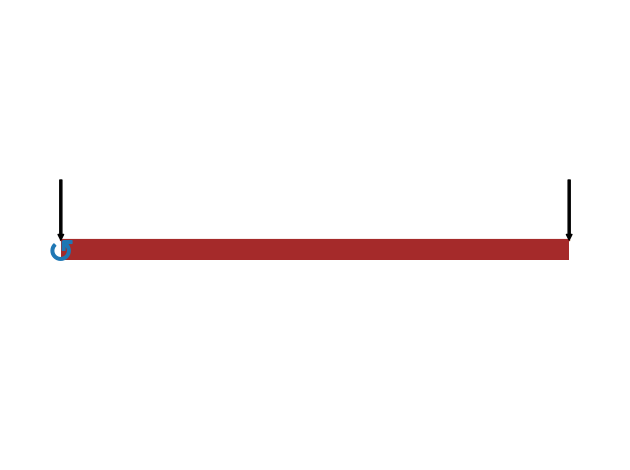

In [70]:
b.draw().show()

In [71]:
b.shear_force()

-80*SingularityFunction(x, 0, -1) + 20*SingularityFunction(x, 0, 0) - 20*SingularityFunction(x, 4, 0)

In [72]:
b.bending_moment()

-80*SingularityFunction(x, 0, 0) + 20*SingularityFunction(x, 0, 1) - 20*SingularityFunction(x, 4, 1)

In [73]:
b.slope()

(-((-80*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 0, 2) - 10*SingularityFunction(x, 4, 2))/I + 120/I)/E + 80.0/(E*I))*SingularityFunction(x, 2, 0) - 0.666666666666667*(-80*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 0, 2) - 10*SingularityFunction(x, 4, 2))*SingularityFunction(x, 0, 0)/(E*I) + 0.666666666666667*(-80*SingularityFunction(x, 0, 1) + 10*SingularityFunction(x, 0, 2) - 10*SingularityFunction(x, 4, 2))*SingularityFunction(x, 2, 0)/(E*I)

Пример 10
----------

Составная балка постоянной изгибной жесткости `E*I` образована присоединением балки длиной `2*l` справа к другой балке длиной `l`. Вся балка защемлена с обоих концов. Сосредоточенная сила величиной `P` приложена сверху на расстоянии `2*l` от начальной точки.

```
                                      ---> x
                                      |
\\\\|                         P       v y |\\\\
\\\\|                         |           |\\\\
\\\\|                         V           |\\\\
\\\\|____________ ________________________|\\\\
\\\\|____________O________________________|\\\\
\\\\|            :            :           |\\\\
\\\\|            :            :           |\\\\
\\\\|------------|------------|-----------|\\\\
         l            l            l
```

In [74]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
l = symbols('l', positive=True)
b1 = Beam(l ,E,I)
b2 = Beam(2*l ,E,I)
b = b1.join(b2,"hinge")
M1, A1, M2, A2, P = symbols('M1 A1 M2 A2 P')
b.apply_load(A1, 0, -1)
b.apply_load(M1, 0 ,-2)
b.apply_load(P, 2*l, -1)
b.apply_load(A2, 3*l, -1)
b.apply_load(M2, 3*l, -2)
b.bc_slope=[(0, 0), (3*l, 0)]
b.bc_deflection=[(0, 0), (3*l, 0)]
b.solve_for_reaction_loads(M1, A1, M2, A2)
b.reaction_loads

{M1: 5*P*l/18, A1: -5*P/18, M2: -4*P*l/9, A2: -13*P/18}

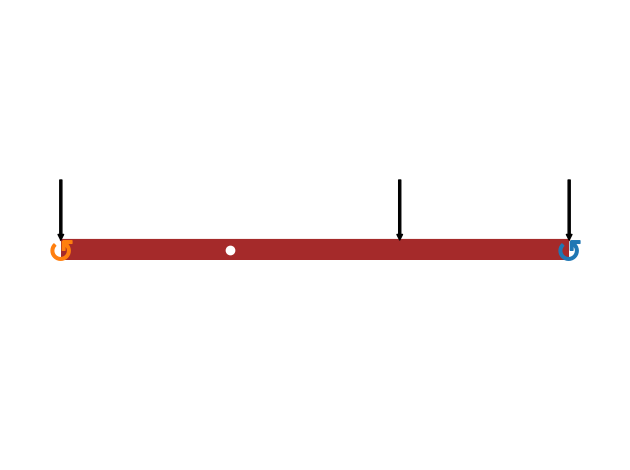

In [76]:
b.draw().show()

In [77]:
b.load

-P*l**2*SingularityFunction(x, l, -3)/12 + 5*P*l*SingularityFunction(x, 0, -2)/18 - 4*P*l*SingularityFunction(x, 3*l, -2)/9 - 5*P*SingularityFunction(x, 0, -1)/18 + P*SingularityFunction(x, 2*l, -1) - 13*P*SingularityFunction(x, 3*l, -1)/18

In [78]:
b.shear_force()

P*l**2*SingularityFunction(x, l, -2)/12 - 5*P*l*SingularityFunction(x, 0, -1)/18 + 4*P*l*SingularityFunction(x, 3*l, -1)/9 + 5*P*SingularityFunction(x, 0, 0)/18 - P*SingularityFunction(x, 2*l, 0) + 13*P*SingularityFunction(x, 3*l, 0)/18

In [79]:
b.bending_moment()

P*l**2*SingularityFunction(x, l, -1)/12 - 5*P*l*SingularityFunction(x, 0, 0)/18 + 4*P*l*SingularityFunction(x, 3*l, 0)/9 + 5*P*SingularityFunction(x, 0, 1)/18 - P*SingularityFunction(x, 2*l, 1) + 13*P*SingularityFunction(x, 3*l, 1)/18

In [80]:
b.slope()

-(P*l**2*SingularityFunction(x, l, 0)/12 - 5*P*l*SingularityFunction(x, 0, 1)/18 + 4*P*l*SingularityFunction(x, 3*l, 1)/9 + 5*P*SingularityFunction(x, 0, 2)/36 - P*SingularityFunction(x, 2*l, 2)/2 + 13*P*SingularityFunction(x, 3*l, 2)/36)/(E*I)

In [81]:
b.deflection()

-(P*l**2*SingularityFunction(x, l, 1)/12 - 5*P*l*SingularityFunction(x, 0, 2)/36 + 2*P*l*SingularityFunction(x, 3*l, 2)/9 + 5*P*SingularityFunction(x, 0, 3)/108 - P*SingularityFunction(x, 2*l, 3)/6 + 13*P*SingularityFunction(x, 3*l, 3)/108)/(E*I)

Пример 11
----------

К балке может быть приложена нагрузка любого вида, заданная полиномом. Это позволяет аппроксимировать произвольные законы распределения нагрузки. В следующем примере показаны шесть усеченных полиномиальных нагрузок, приложенных по длине балки.

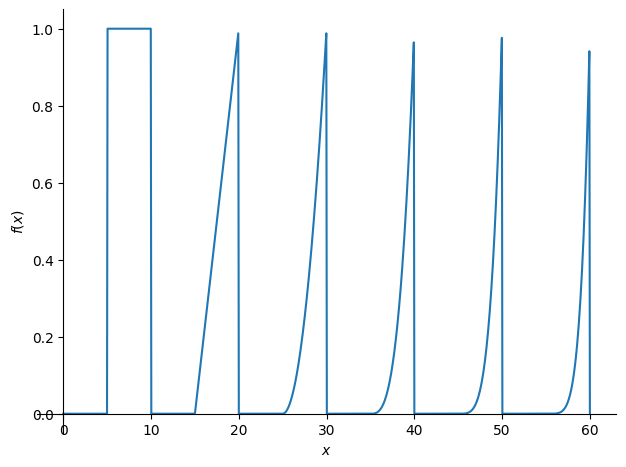

In [ ]:
from sympy import Symbol
x = Symbol('x')
n = 6
b = Beam(10*n, E, I)
for i in range(n):
    b.apply_load(1 / (5**i), 10*i + 5, i, end=10*i + 10)
plot(b.load, (x, 0, 10*n));

Пример 12
----------

Та же балка, что и в Примере 10, но с использованием методов `apply_rotation_hinge()` и `apply_support()`.

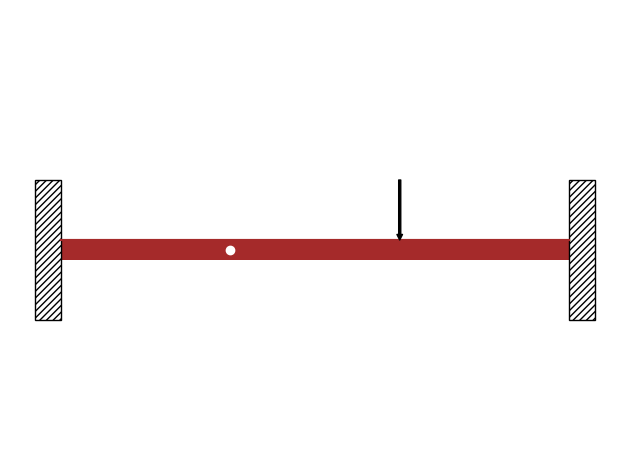

In [90]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols
E, I = symbols('E, I')
l = symbols('l', positive=True)
b = Beam(3*l, E, I)
r0,m0 = b.apply_support(0, type='fixed')
r3l,m3l = b.apply_support(3*l, type='fixed')
F = symbols('F')
p1 = b.apply_rotation_hinge(l)
b.apply_load(F, 2*l, -1)
b.solve_for_reaction_loads(r0,m0,r3l,m3l)
b.reaction_loads
b.draw().show()

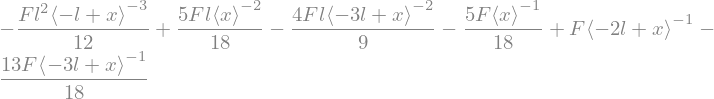

In [91]:
b.load

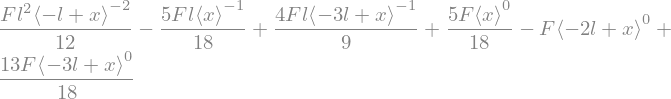

In [92]:
b.shear_force()

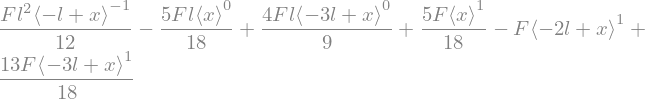

In [93]:
b.bending_moment()

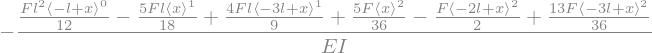

In [94]:
b.slope()

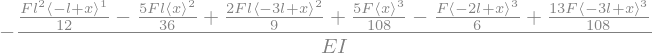

In [95]:
b.deflection()

Пример 13
----------

Имеется балка длиной `3*l`, защемленная с обоих концов. Сосредоточенная сила приложена на расстоянии `l/3`, а распределенная нагрузка `q1` приложена на участке между `2*l` и `3*l`. Балка имеет скользящий шарнир, расположенный в точке `l*5/2`, заданный с помощью метода `apply_sliding_hinge()`.

> [!note]
> Можно использовать `l*5/2` в качестве входных данных, однако хорошей практикой является использование `Rational(5, 2)`. Это помогает решателю интерпретировать входное значение как дробь и получать точные, а не приближенные решения в виде чисел с плавающей запятой.

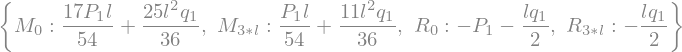

In [99]:
from sympy.physics.continuum_mechanics.beam import Beam
from sympy import symbols, Rational
E, I = symbols('E, I')
l = symbols('l', positive=True)
b = Beam(3*l, E, I)
r0, m0 = b.apply_support(0, type='fixed')
r3l, m3l = b.apply_support(3*l, type='fixed')
s1 = b.apply_sliding_hinge(l*Rational(5, 2))
P1, q1 = symbols('P1 q1')
b.apply_load(P1, l*Rational(1, 3), -1)
b.apply_load(q1, 2*l, 0, 3*l)
b.solve_for_reaction_loads(r0, r3l, m0, m3l)
b.reaction_loads

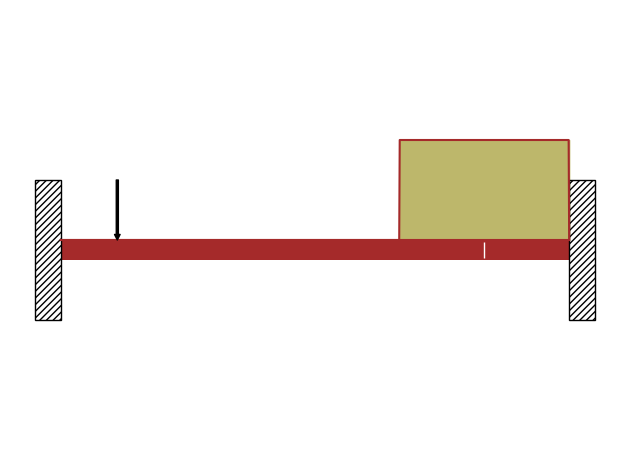

In [100]:
b.draw().show()

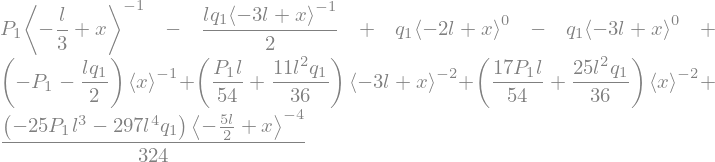

In [101]:
b.load

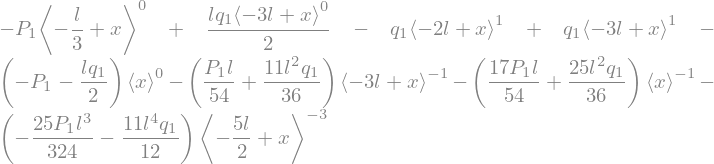

In [102]:
b.shear_force()

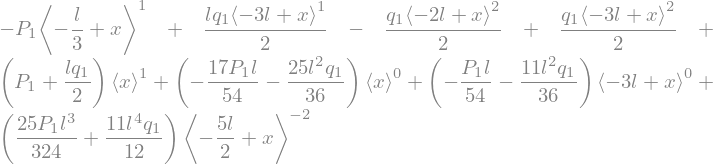

In [103]:
b.bending_moment()

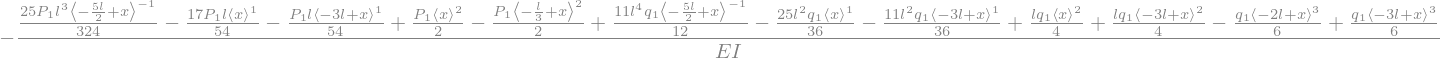

In [104]:
b.slope()

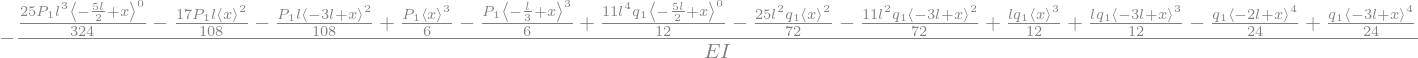

In [105]:
b.deflection()